In [2]:
# (Dùng các nguyên lý đếm cơ bản để đếm số chu trình tối giản trong các vòng lặp xác định) Cho đoạn chương trình
# for i = 1 to n do
#     for j = 1 to i do
#         for k = 1 to j - 1 do
#             print i, j, k
# 1) Với n = 5, chương trình thực hiện bao nhiêu lệnh print
# 2) Với n bất kỳ, chương trình thực hiện bao nhiêu lệnh print
# 3) Cho biết độ phức tạp tính toán của chương trình

#Giải
# Mỗi lệnh print ứng với một bộ (i, j, k) được in ra, với 1 ≤ k ≤ j ≤ i ≤ n.
# Đó chính là tổ hợp lặp chập 3 của n số 1, 2, ... , n. Do đó số lệnh print được thực
# hiện là
print("C(n+3 - 1, 3) = C(n+2,3) = (n+2)! (n+1)n / 3! = n(n+1)(n+2) / 6")
i, j, k, n = sp.symbols('i j k n', integer=True)
expr = sp.Sum(1, (k, 1, j), (j, 1, i), (i, 1, n))
result = expr.doit().simplify().factor()
print(result)
def evaluate_sum(n_value):
    i, j, k, n = sp.symbols('i j k n', integer=True)
    expr = sp.Sum(1, (k, 1, j ), (j, 1, i), (i, 1, n))
    result = expr.doit().simplify().factor()
    return result.subs(n, n_value).evalf()

print(evaluate_sum(5))



C(n+3 - 1, 3) = C(n+2,3) = (n+2)! (n+1)n / 3! = n(n+1)(n+2) / 6


NameError: name 'sp' is not defined

# Chứng minh bằng phương pháp quy nạp toán học

## Bài toán 1: Chứng minh đẳng thức

$$
\sum_{i=1}^n \frac{1}{i(i+1)} = \frac{n}{n+1}, \quad \forall n \in \mathbb{Z}^+
$$

### Bước 1: Giả sử với n thuộc Z+, biểu thức đúng ta có:


$$
\sum_{i=1}^k \frac{1}{i(i+1)} = \frac{k}{k+1}
$$

$$
\sum_{i=1}^{k+1} \frac{1}{i(i+1)} = \frac{k+1}{k+2}
$$

### Khi đó

Xét tổng:

$$
\sum_{i=1}^{k+1} \frac{1}{i(i+1)} = \left(\sum_{i=1}^k \frac{1}{i(i+1)}\right) + \frac{1}{(k+1)(k+2)}
$$

Theo giả thuyết quy nạp, ta có:

$$
= \frac{k}{k+1} + \frac{1}{(k+1)(k+2)} = \frac{k(k+2)}{(k+1)(k+2)} + \frac{1}{(k+1)(k+2)} = \frac{k(k+2) + 1}{(k+1)(k+2)}
$$

Tính tử số:

$$
k(k+2) + 1 = k^2 + 2k + 1 = (k+1)^2
$$

Do đó:

$$
\sum_{i=1}^{k+1} \frac{1}{i(i+1)} = \frac{(k+1)^2}{(k+1)(k+2)} = \frac{k+1}{k+2}
$$

Tức là biểu thức đúng với n = k+1

Vậy, theo nguyên lý quy nạp ta có đpcm.

---

## Bài toán 2: Tính chất dãy Fibonacci

Chứng minh:

$$
F_{n+2} = 1 + F_1 + F_2 + \cdots + F_n, \quad \forall n \in \mathbb{Z}^+
$$

với dãy Fibonacci được định nghĩa bởi:

$$
F_1 = 1, \quad F_2 = 1, \quad F_{n} = F_{n-1} + F_{n-2} \quad \text{với } n \ge 3
$$

### Bước 1: Cơ sở quy nạp

Với $n=1$:

$$
F_3 = F_1 + F_2 = 1 + 1 = 2
$$

Tính tổng:

$$
1 + F_1 = 1 + 1 = 2
$$

Vậy công thức đúng với $n=1$.

### Bước 2: Giả thuyết quy nạp

Giả sử công thức đúng với $n = k$:

$$
F_{k+2} = 1 + \sum_{i=1}^k F_i
$$

### Bước 3: Chứng minh với $n = k+1$

Ta cần chứng minh:

$$
F_{k+3} = 1 + \sum_{i=1}^{k+1} F_i
$$

Từ định nghĩa dãy Fibonacci:

$$
F_{k+3} = F_{k+2} + F_{k+1}
$$

Theo giả thuyết quy nạp:

$$
F_{k+2} = 1 + \sum_{i=1}^k F_i
$$

Do đó:

$$
F_{k+3} = \left(1 + \sum_{i=1}^k F_i \right) + F_{k+1} = 1 + \sum_{i=1}^k F_i + F_{k+1} = 1 + \sum_{i=1}^{k+1} F_i
$$

### Kết luận:

Vậy, công thức đúng với mọi $n \in \mathbb{Z}^+$.


In [ ]:
#Câu 3a:
import numpy as np
# Ma trận quan hệ ban đầu (kiểu boolean)
M = np.array([
    [0, 1, 0, 1,1],
    [0, 1, 0, 0,0],
    [1, 0, 0, 0,0],
    [0, 0, 1, 0,0],
    [0, 0, 0, 1,0],
], dtype=bool)

n = len(M)

# Khởi tạo A là M, để lưu tổng M + M^2 + ... + M^k
A = M.copy()

# Biến tạm L để nhân lũy thừa
L = M.copy()

# Tính các lũy thừa từ M^2 đến M^n và cộng dồn vào A
for k in range(2, n + 1):
    L = M.dot(L)        # M^k = M * M^{k-1}
    A += L              # Cộng dồn vào A: A = M + M^2 + ... + M^k
    print(f"M^{k}:\n", np.array(L, dtype=int))  # In ra M^k dưới dạng int
print("M* = M1 v M2 .. V Mn")
# In bao đóng bắc cầu (dưới dạng 0/1)
print("Transitive Closure (M*):\n", np.array(A, dtype=int))


M^2:
 [[0 1 1 1 0]
 [0 1 0 0 0]
 [0 1 0 1 1]
 [1 0 0 0 0]
 [0 0 1 0 0]]
M^3:
 [[1 1 1 0 0]
 [0 1 0 0 0]
 [0 1 1 1 0]
 [0 1 0 1 1]
 [1 0 0 0 0]]
M^4:
 [[1 1 0 1 1]
 [0 1 0 0 0]
 [1 1 1 0 0]
 [0 1 1 1 0]
 [0 1 0 1 1]]
M^5:
 [[0 1 1 1 1]
 [0 1 0 0 0]
 [1 1 0 1 1]
 [1 1 1 0 0]
 [0 1 1 1 0]]
M* = M1 v M2 .. V Mn
Transitive Closure (M*):
 [[1 1 1 1 1]
 [0 1 0 0 0]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


# Câu 3b:
Xét dãy ma trận $W^{(k)} = [w_{ij}^{(k)}]_n$ được xác định bởi:

1. $W^{(0)} = M_R$, và  
2. Với $k = 1, 2, \dots, n$:

$$
w_{ij}^{(k)} = w_{ij}^{(k-1)} \lor \left(w_{ik}^{(k-1)} \land w_{kj}^{(k-1)}\right)
$$

(M1 gạch cột 1 hàng 1 cóp sang M2, các vị trí của M2 = vị trí tương ứng M1 + gióng cột * gióng hàng)



1) Xác định ma trận biểu diễn M(R) (Dễ vl)
2) Chứng minh R là quan hệ thứ tự
*Phản xứng
Quan hệ là phản xạ vì mii = 1 với mọi i chạy từ 1,n

Ma trận chuyển vị M.T:
[[1 0 1 0 1 0]
 [0 1 0 0 0 0]
 [0 0 1 0 0 0]
 [1 0 1 1 1 0]
 [0 0 0 0 1 0]
 [0 1 0 0 0 1]]

Ma trận M ∧ M.T:
[[1 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 1]]

✅ Quan hệ là phản xứng.
*Bác cầu
Ma trận M:
[[1 0 0 1 0 0]
 [0 1 0 0 0 1]
 [1 0 1 1 0 0]
 [0 0 0 1 0 0]
 [1 0 0 1 1 0]
 [0 0 0 0 0 1]]

Ma trận M^2 (M nhân logic với M):
[[1 0 0 1 0 0]
 [0 1 0 0 0 1]
 [1 0 1 1 0 0]
 [0 0 0 1 0 0]
 [1 0 0 1 1 0]
 [0 0 0 0 0 1]]

Kiểm tra M^2 ⊆ M (tức là M^2 <= M):

✅ Quan hệ là bắc cầu.
M là quan hệ thứ tự vì tm 3 điều kiện
3) Xác định các phần tử tối đại / tối tiểu A theo quan hệ thứ tự R
x tối đại <-> với mọi a thuộc A,(x,a) không thuộc R (ngang chỉ có 1 cột = 1)
x tối tiểu <-> với mọi a thuộc A,(a,x) không thuộc R (dọc chỉ có 1 hàng = 1)
Ma trận quan hệ R:
[[1 0 0 1 0 0]
 [0 1 0 0 0 1]
 [1 0 

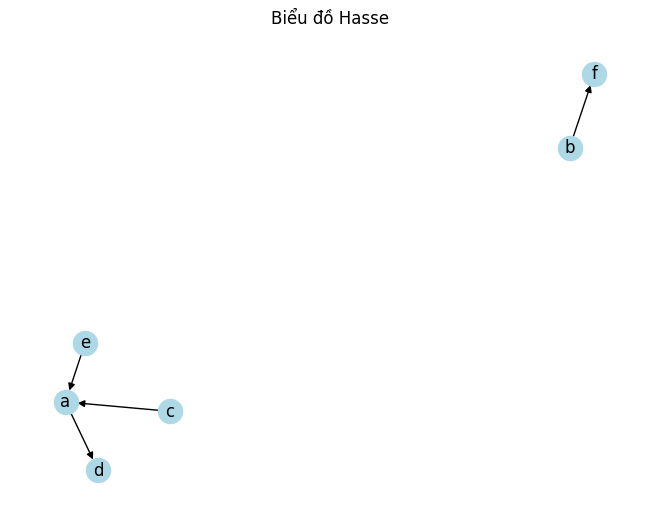

In [ ]:
#Câu 4:
print("1) Xác định ma trận biểu diễn M(R) (Dễ vl)")
print("2) Chứng minh R là quan hệ thứ tự")
M = np.array([
    [1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 1],
    [1, 0, 1, 1, 0, 0],
    [0, 0, 0, 1, 0, 0],     #--> Tối đại (ngang chỉ có 1 cột = 1)
    [1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 1]      #--> Tối đại
    #    |       |
    #    |       |
    # Tối tiểu (dọc chỉ có 1 hàng = 1)

], dtype=bool)
def phanXa(M):
    n = M.shape[0]
    for i in range(n):
        if M[i, i] != 1:
            print("Quan hệ không phản xạ.")
            return
    print("Quan hệ là phản xạ vì mii = 1 với mọi i chạy từ 1,n")
print("*Phản xứng")
phanXa(M)
#Phản xứng vì 
def phanXung(M):
    n = M.shape[0]
    identity = np.eye(n, dtype=bool)
    symmetric_and = np.logical_and(M, M.T)
    
    print("\nMa trận chuyển vị M.T:")
    print(M.T.astype(int))
    
    print("\nMa trận M ∧ M.T:")
    print(symmetric_and.astype(int))

    # Kiểm tra phản xứng: M ∧ M.T ≤ I
    if np.all(np.logical_or(symmetric_and == False, identity)):
        print("\n✅ Quan hệ là phản xứng.")
    else:
        print("\n❌ Quan hệ không phản xứng.")
phanXung(M)
import numpy as np
print("*Bác cầu")
def bacCau(M):
    n = M.shape[0]

    # Nhân logic: dùng toán tử dot, sau đó ép kiểu về bool (vì True = 1, False = 0)
    M_squared = (M @ M) > 0  # hoặc: np.dot(M, M) > 0

    print("Ma trận M:")
    print(M.astype(int))

    print("\nMa trận M^2 (M nhân logic với M):")
    print(M_squared.astype(int))

    print("\nKiểm tra M^2 ⊆ M (tức là M^2 <= M):")
    inclusion = np.logical_or(np.logical_not(M_squared), M)

    if np.all(inclusion):
        print("\n✅ Quan hệ là bắc cầu.")
    else:
        print("\n❌ Quan hệ không bắc cầu.")
bacCau(M)
print("M là quan hệ thứ tự vì tm 3 điều kiện")
print("3) Xác định các phần tử tối đại / tối tiểu A theo quan hệ thứ tự R")
print("x tối đại <-> với mọi a thuộc A,(x,a) không thuộc R (ngang chỉ có 1 cột = 1)")
print("x tối tiểu <-> với mọi a thuộc A,(a,x) không thuộc R (dọc chỉ có 1 hàng = 1)")
def toiDaiTieu(M):
    n = M.shape[0]

    print("Ma trận quan hệ R:")
    print(M.astype(int))

    maximal_elements = []
    minimal_elements = []

    for i in range(n):
        # Tối đại: hàng i chỉ có 1 phần tử 1 (tại vị trí [i][i])
        if np.sum(M[i, :]) == 1 and M[i, i] == 1:
            maximal_elements.append(i+1)

        # Tối tiểu: cột i chỉ có 1 phần tử 1 (tại vị trí [i][i])
        if np.sum(M[:, i]) == 1 and M[i, i] == 1:
            minimal_elements.append(i+1)

    print("\n🔼 Phần tử tối đại (chỉ số):", maximal_elements)
    print("🔽 Phần tử tối tiểu (chỉ số):", minimal_elements)
toiDaiTieu(M)
print("4) Biểu đồ hass")
def hass(M, labels=None):
    n = M.shape[0]
    # Loại bỏ phản xạ
    np.fill_diagonal(M, 0)

    # Loại bỏ các quan hệ bắc cầu
    M_transitive = (M @ M) > 0
    M = M & ~M_transitive

    G = nx.DiGraph()
    for i in range(n):
        G.add_node(i)

    for i in range(n):
        for j in range(n):
            if M[i][j]:
                G.add_edge(i, j)

    pos = nx.spring_layout(G)  # dùng layout để vẽ đẹp
    if labels is None:
        labels = {i: str(i) for i in range(n)}
    else:
        labels = {i: labels[i] for i in range(n)}

    nx.draw(G, pos, with_labels=True, labels=labels, node_color='lightblue', arrows=True)
    plt.title("Biểu đồ Hasse")
    plt.show()
hass(M,labels=['a', 'b', 'c', 'd','e','f'])

In [ ]:
#Câu 5:
print("1) Xác định ma trận biểu diễn M(R) (Dễ vl)")
print("2) Chứng minh R là quan hệ tương đương")
M = np.array([
    [1, 0, 1, 1, 0, 1],
    [0, 1, 0, 0, 1, 0],
    [1, 0, 1, 1, 0, 1],
    [1, 0, 1, 1, 0, 1],     
    [0, 1, 0, 0, 1, 0],
    [1, 0, 1, 1, 0, 1]    
], dtype=bool)  
print("*Phản xạ")
def phanXa(M):
    n = M.shape[0]
    for i in range(n):
        if M[i, i] != 1:
            print("Quan hệ không phản xạ.")
            return
    print("Quan hệ là phản xạ vì mii = 1 với mọi i chạy từ 1,n")
phanXa(M)
print("*Đối xứng")
def doiXung(M):
    print("Ma trận M:")
    print(M.astype(int))  # In dưới dạng số nguyên
    print("Ma trận chuyển vị M^T:")
    print(M.T.astype(int))

    if np.array_equal(M, M.T):
        print("✅ Quan hệ là đối xứng vì M = M^T.")
        return True
    else:
        print("❌ Quan hệ không đối xứng.")
        return False
doiXung(M)
print("*Bác cầu")
def bacCau(M):
    n = M.shape[0]

    # Nhân logic: dùng toán tử dot, sau đó ép kiểu về bool (vì True = 1, False = 0)
    M_squared = (M @ M) > 0  # hoặc: np.dot(M, M) > 0

    print("Ma trận M:")
    print(M.astype(int))

    print("\nMa trận M^2 (M nhân logic với M):")
    print(M_squared.astype(int))

    print("\nKiểm tra M^2 ⊆ M (tức là M^2 <= M):")
    inclusion = np.logical_or(np.logical_not(M_squared), M)

    if np.all(inclusion):
        print("\n✅ Quan hệ là bắc cầu.")
    else:
        print("\n❌ Quan hệ không bắc cầu.")
bacCau(M)
print("R là qh tương đương vì tm 3 thuộc tính trên")
print("3)Xác định lớp tương đương")
def lopTuongDuong(M, labels=None):
    n = M.shape[0]
    visited = [False] * n
    classes = []

    for i in range(n):
        if not visited[i]:
            lop = [i]
            visited[i] = True
            for j in range(n):
                if M[i][j] and M[j][i]:
                    if not visited[j]:
                        lop.append(j)
                        visited[j] = True
            classes.append(lop)

    # In kết quả
    print("Các lớp tương đương:")
    for cls in classes:
        if labels:
            print("{ " + ", ".join(labels[i] for i in cls) + " }")
        else:
            print("{ " + ", ".join(str(i) for i in cls) + " }")
    return classes
lopTuongDuong(M,labels=['a', 'b', 'c', 'd','e','f'])


1) Xác định ma trận biểu diễn M(R) (Dễ vl)
2) Chứng minh R là quan hệ tương đương
*Phản xạ
Quan hệ là phản xạ vì mii = 1 với mọi i chạy từ 1,n
*Đối xứng
Ma trận M:
[[1 0 1 1 0 1]
 [0 1 0 0 1 0]
 [1 0 1 1 0 1]
 [1 0 1 1 0 1]
 [0 1 0 0 1 0]
 [1 0 1 1 0 1]]
Ma trận chuyển vị M^T:
[[1 0 1 1 0 1]
 [0 1 0 0 1 0]
 [1 0 1 1 0 1]
 [1 0 1 1 0 1]
 [0 1 0 0 1 0]
 [1 0 1 1 0 1]]
✅ Quan hệ là đối xứng vì M = M^T.
*Bác cầu
Ma trận M:
[[1 0 1 1 0 1]
 [0 1 0 0 1 0]
 [1 0 1 1 0 1]
 [1 0 1 1 0 1]
 [0 1 0 0 1 0]
 [1 0 1 1 0 1]]

Ma trận M^2 (M nhân logic với M):
[[1 0 1 1 0 1]
 [0 1 0 0 1 0]
 [1 0 1 1 0 1]
 [1 0 1 1 0 1]
 [0 1 0 0 1 0]
 [1 0 1 1 0 1]]

Kiểm tra M^2 ⊆ M (tức là M^2 <= M):

✅ Quan hệ là bắc cầu.
R là qh tương đương vì tm 3 thuộc tính trên
3)Xác định lớp tương đương
Các lớp tương đương:
{ a, c, d, f }
{ b, e }


Một lớp tương đương của phần tử $a \in A$ theo quan hệ tương đương $R$ được định nghĩa là:

$$
[a] = \{ x \in A \mid x \mathrel{R} a \}
$$

Tập hợp các lớp tương đương tạo thành một phân hoạch của tập $A$.


### Câu 6:
## Định nghĩa hàm đệ quy `f(n)`

Hàm `f(n)` được định nghĩa như sau:

```python
def f(n): 
    if n == 0:
        return 1
    x = 2
    for i in range(3):
        x = x + f(n - 1)
    for i in range(n):
        x = x + 4
    return x



## 1) Tính $f_1$, $f_2$, $f_3$ 

Giả sử $f_0 = 1$

$$
\begin{aligned}
f_1 &= 2 + 3 \cdot f_0 + 4 \cdot 1 = 2 + 3 \cdot 1 + 4 = 9 \\
f_2 &= 2 + 3 \cdot f_1 + 4 \cdot 2 = 2 + 3 \cdot 9 + 8 = 2 + 27 + 8 = 37 \\
f_3 &= 2 + 3 \cdot f_2 + 4 \cdot 3 = 2 + 3 \cdot 37 + 12 = 2 + 111 + 12 = 125
\end{aligned}
$$

---

## 2) Đặt $a_n$ là số phép toán (số học, so sánh, gán) dùng để tính $f_n$. Xác định hệ thức đệ quy cho $a_n$ và giải nó.

### Với $n = 0$:

- Dòng 2: 1 phép so sánh  
$$\Rightarrow a_0 = 1$$

### Với $n > 0$:

- Dòng 2: 1 phép so sánh  
- Dòng 3: 1 phép gán  
- Dòng 4–5:
  - Mỗi lần lặp: 1 phép gọi đệ quy $f(n-1)$ và 1 phép cộng  
  - Gọi 3 lần $\Rightarrow$ số phép toán: $3 \cdot (a_{n-1} + 1)$  
- Dòng 6–7:
  - Mỗi lần lặp: 1 phép cộng ($x = x + 4$)  
  - Lặp $n$ lần $\Rightarrow n$ phép toán

Tổng cộng:

- So sánh + gán: $2$
- Đệ quy và cộng trong vòng lặp đầu: $3(a_{n-1} + 1) = 3a_{n-1} + 3$
- Vòng lặp thứ hai: $n$ phép toán

$$
\Rightarrow a_n = 2 + 3a_{n-1} + 3 + n = 3a_{n-1} + n + 5
$$

---

## 3) Giải hệ đệ quy $a_n = 3a_{n-1} + n + 5$ với $a_0 = 1$

Đây là hệ đệ quy tuyến tính không thuần nhất. Ta giải như sau:

### Bước 1: Giải nghiệm riêng cho hệ thuần nhất

$$
a_n^h = 3a_{n-1}^h \Rightarrow a_n^h = A \cdot 3^n
$$

### Bước 2: Tìm nghiệm riêng cho hệ đầy đủ

Dự đoán nghiệm riêng dạng: $a_n^p = Bn + C$

Thay vào:

$$
\begin{aligned}
Bn + C &= 3(B(n - 1) + C) + n + 5 \\
       &= 3Bn - 3B + 3C + n + 5 \\
       &= 3Bn + n + (3C - 3B + 5)
\end{aligned}
$$

So sánh hệ số:

- $B = 3B + 1 \Rightarrow -2B = 1 \Rightarrow B = -\dfrac{1}{2}$  
- $C = 3C - 3B + 5$

Thay $B = -\dfrac{1}{2}$:

$$
\begin{aligned}
C &= 3C + \dfrac{3}{2} + 5 \\
-2C &= \dfrac{13}{2} \Rightarrow C = -\dfrac{13}{4}
\end{aligned}
$$

Vậy nghiệm riêng:  
$$
a_n^p = -\dfrac{1}{2}n - \dfrac{13}{4}
$$

### Bước 3: Tổng nghiệm

$$
a_n = A \cdot 3^n - \dfrac{1}{2}n - \dfrac{13}{4}
$$

Thay $a_0 = 1$ để tìm $A$:

$$
\begin{aligned}
1 &= A \cdot 3^0 - 0 - \dfrac{13}{4} \\
A &= 1 + \dfrac{13}{4} = \dfrac{17}{4}
\end{aligned}
$$

---

## ✅ Kết quả cuối cùng:

- $f_1 = 9$, $f_2 = 37$, $f_3 = 125$
- Hệ thức đệ quy: $a_n = 3a_{n-1} + n + 5$, với $a_0 = 1$
- Nghiệm tổng quát:  
$$
a_n = \dfrac{17}{4} \cdot 3^n - \dfrac{1}{2}n - \dfrac{13}{4}
$$
